In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [7]:
bgg_games = pd.read_csv('../data/source/bgg_games.csv')

In [8]:
bgg_games['rank_boardgame'] = pd.to_numeric(bgg_games['rank_boardgame'], errors='coerce')
bgg_games.sort_values('rank_boardgame', ascending=True,inplace=True)
bgg_games.head()

,row_id,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,trading,wanting,wishing,rank_boardgame
0,224517,boardgame,Brass: Birmingham,2,4,120,14,2018,8.56433,58318,3.8607,2850,8.39353,1.42790,1: No necessary in-game text,83744,367,1754,21874,1.0
10208,342942,boardgame,Ark Nova,1,4,150,14,2021,8.54058,60867,3.7963,3118,8.35456,1.40476,4: Extensive use of text - massive conversion ...,88580,447,1071,17713,2.0
19801,161936,boardgame,Pandemic Legacy: Season 1,2,4,60,13,2015,8.50255,57354,2.8278,1556,8.34628,1.60876,4: Extensive use of text - massive conversion ...,89321,524,807,15019,3.0
21431,174430,boardgame,Gloomhaven,1,4,120,14,2017,8.53957,67111,3.9187,2755,8.29747,1.73643,4: Extensive use of text - massive conversion ...,104470,1306,1158,22286,4.0
22517,397598,boardgame,Dune: Imperium – Uprising,1,6,120,13,2023,8.70003,18269,3.5243,576,8.23575,1.33245,3: Moderate in-game text - needs crib sheet or...,28205,82,886,7794,5.0


In [9]:
variables_graficas =['rank_boardgame', 'average_rating', 'release_year', 'playingtime', 'weight', 'min_players', 'max_players','bayes_average']
df = bgg_games[variables_graficas].copy()
df.head()


,rank_boardgame,average_rating,release_year,playingtime,weight,min_players,max_players,bayes_average
0,1.0,8.56433,2018,120,3.8607,2,4,8.39353
10208,2.0,8.54058,2021,150,3.7963,1,4,8.35456
19801,3.0,8.50255,2015,60,2.8278,2,4,8.34628
21431,4.0,8.53957,2017,120,3.9187,1,4,8.29747
22517,5.0,8.70003,2023,120,3.5243,1,6,8.23575


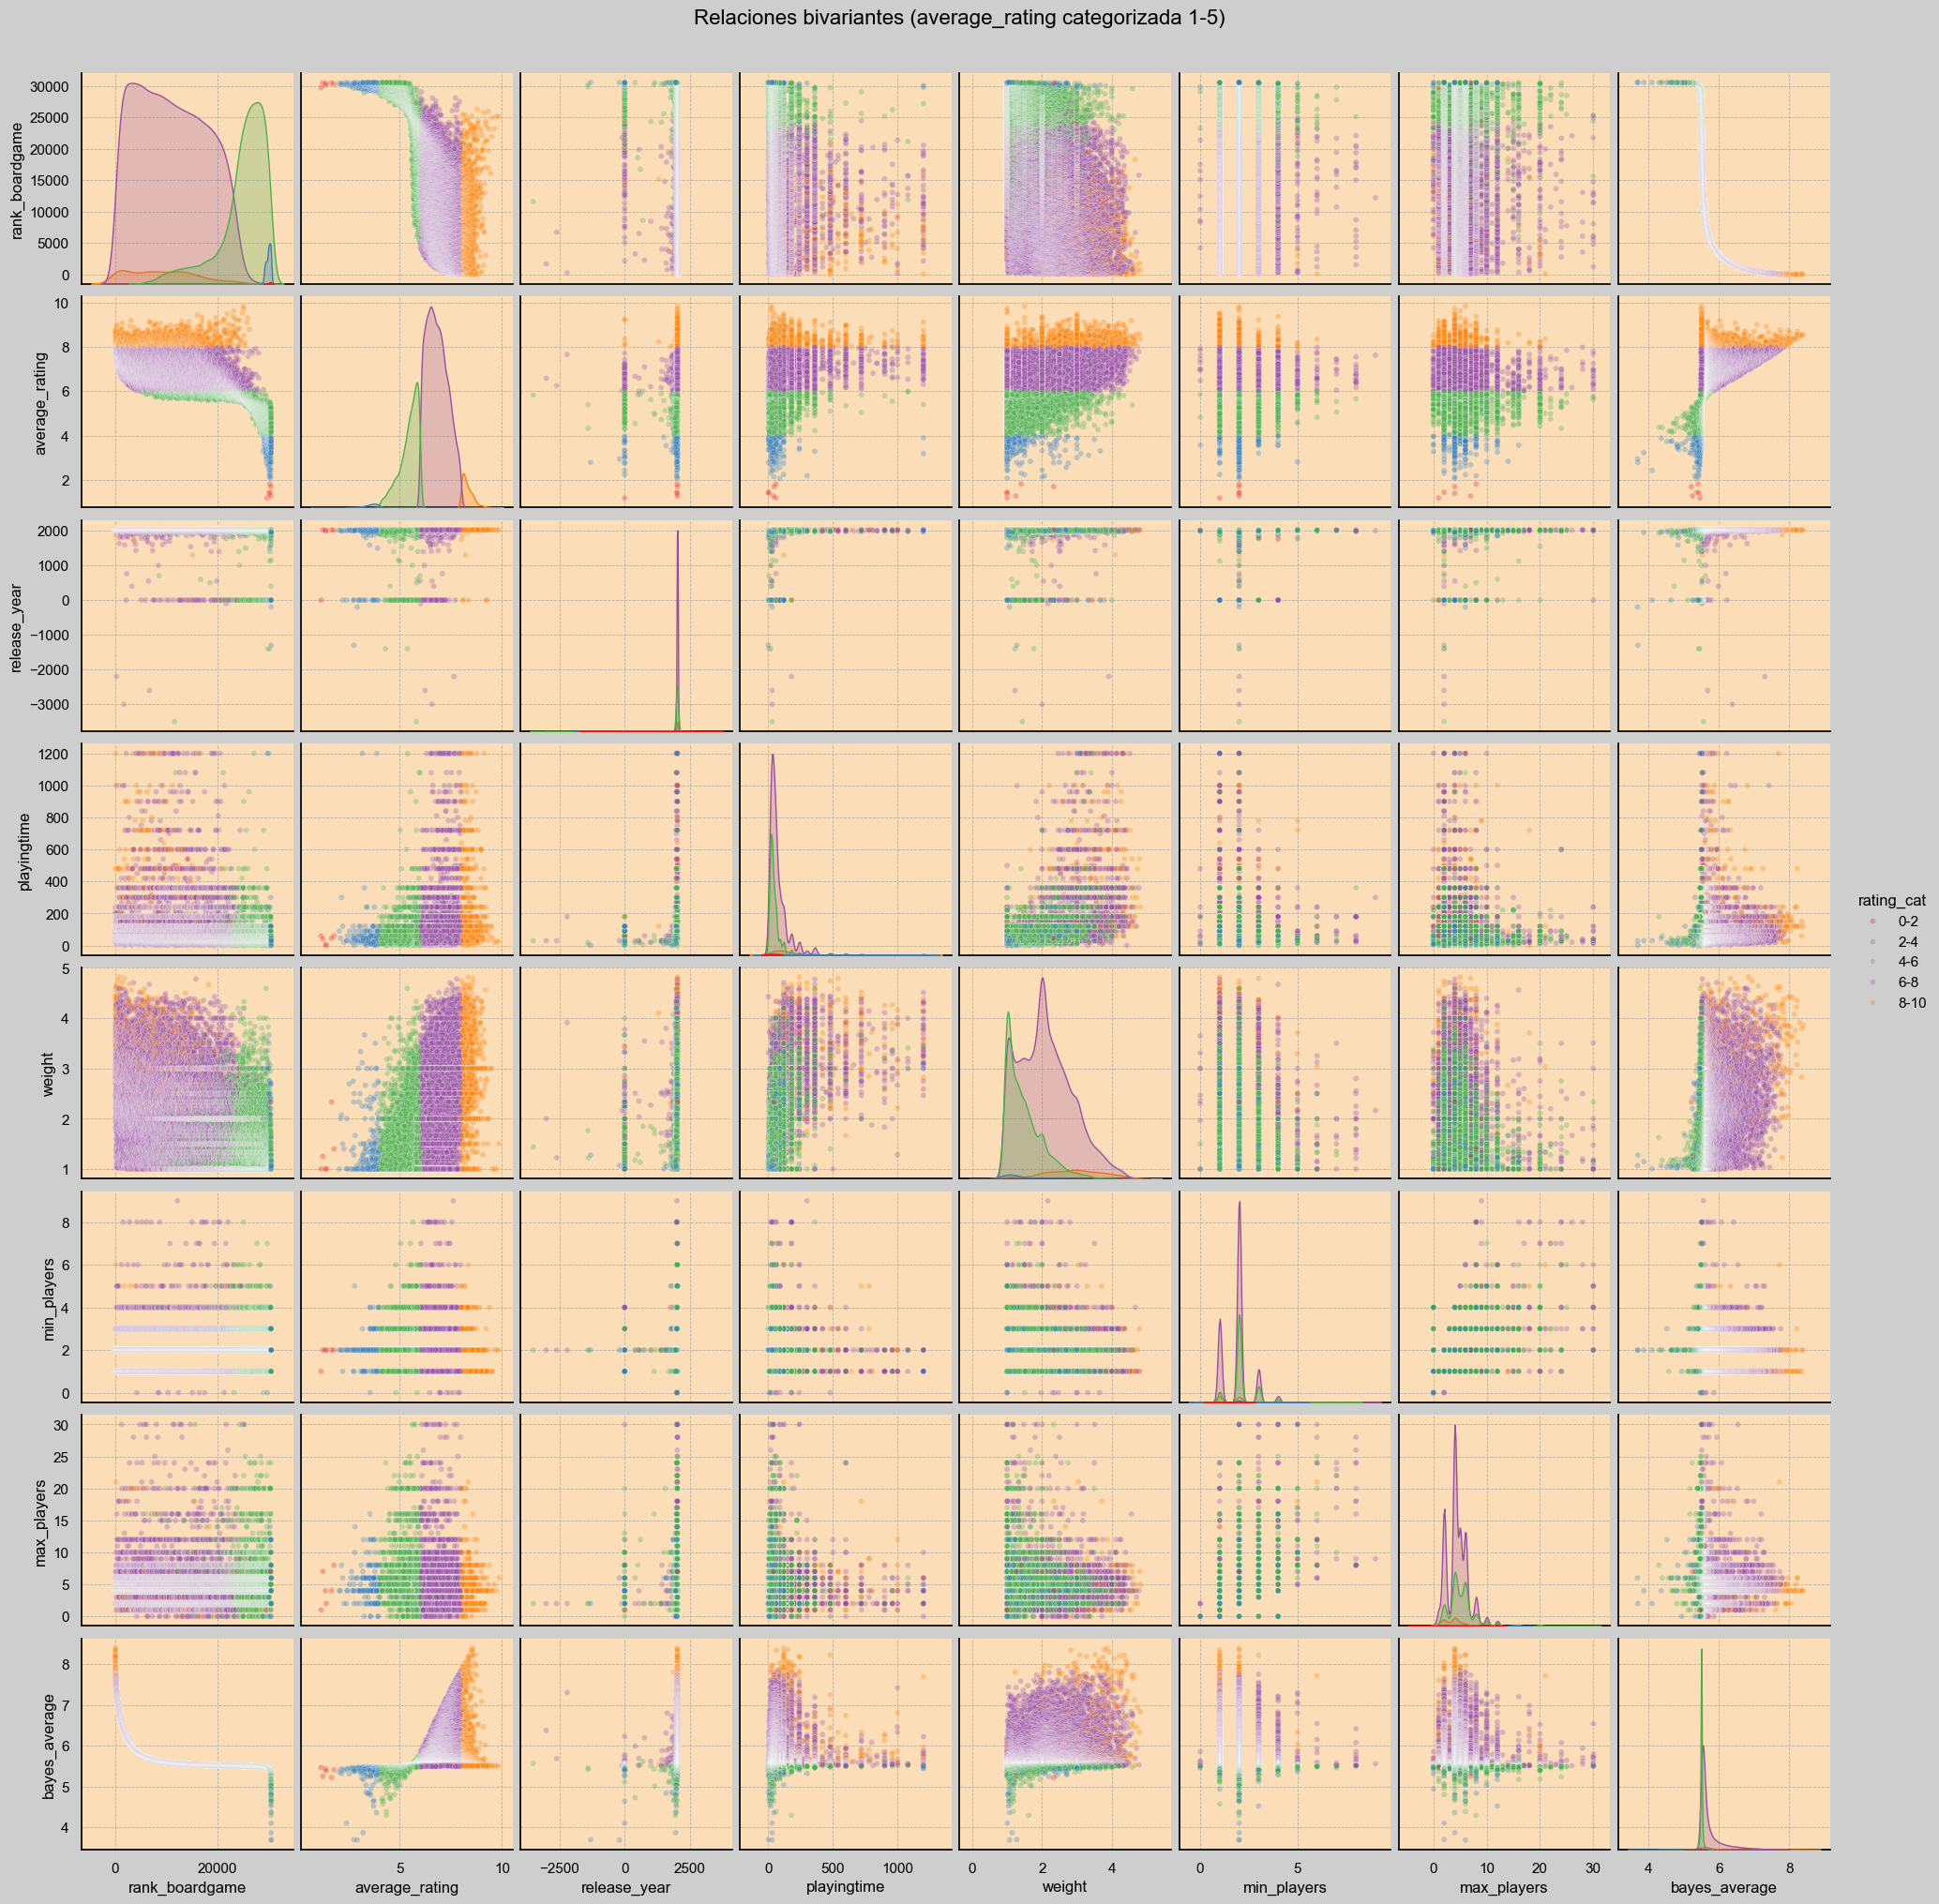

In [ ]:
#-- IGNORE --
# Convertimos average_rating a categoría 1-5
df_plot = df.dropna().copy()

df_plot['rating_cat'] = pd.cut(
    df_plot['average_rating'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=["0-2", "2-4", "4-6", "6-8", "8-10"],
    include_lowest=True
).astype('category')

vars_estudio = [c for c in df_plot.columns if c not in ['rating_cat']]
paleta = sns.color_palette("Set1", 5)


g = sns.pairplot(
    df_plot,
    vars=vars_estudio,
    hue='rating_cat',
    hue_order=["0-2", "2-4", "4-6", "6-8", "8-10"],
    palette=paleta,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 20}
)

g.figure.patch.set_facecolor(fondo_global)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(fondo_grafico)
        ax.grid(True, which='major', color='#B8B0A3', linestyle='--', linewidth=0.6)

g.figure.suptitle('Relaciones bivariantes (average_rating categorizada 1-5)', y=1.02, color="black", fontsize=16)


plt.show()

<Axes: >

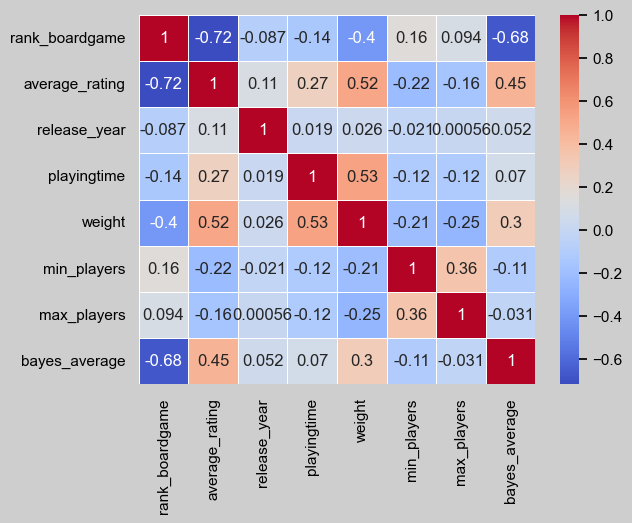

In [11]:
correlation_matrix = df_plot.select_dtypes(include=[np.number]).corr()
plt.Figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white')

In [ ]:
def subplot_pairplot(df, xindex,yindex,xlabel,ylabel, color_graf, **params_grafico):
    ax = g.axes[xindex, yindex]

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=df,
        x=xlabel,
        y=ylabel,
        hue=color_graf,
        ax=ax2,
        **params_grafico
    )

    ax2.legend(markerscale=1.5, title='Rating Category',loc = 'best')
    fig2.tight_layout()
    plt.show()


In [5]:
subplot_pairplot(df_plot, 4, 5,'weight',  'min_players', 'rating_cat',legend='brief')

NameError: name 'subplot_pairplot' is not defined

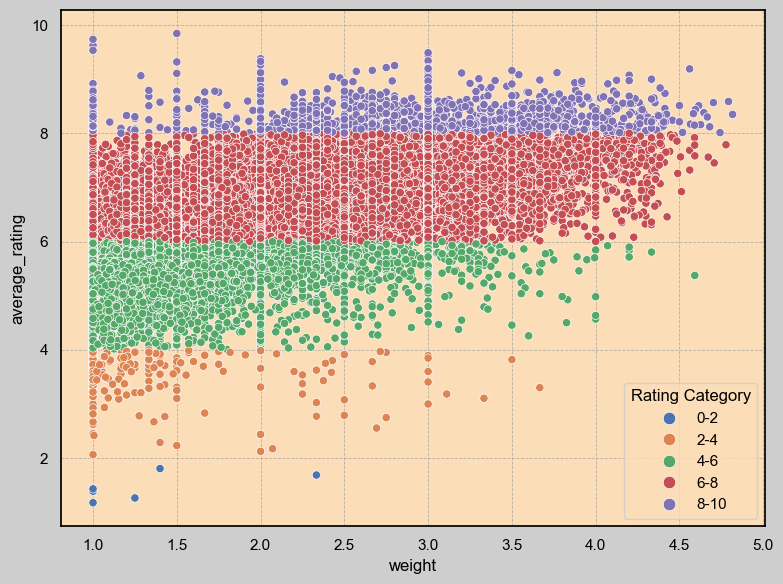

In [20]:
subplot_pairplot(df_plot, 4, 1,'weight',  'average_rating', 'rating_cat',legend='brief')

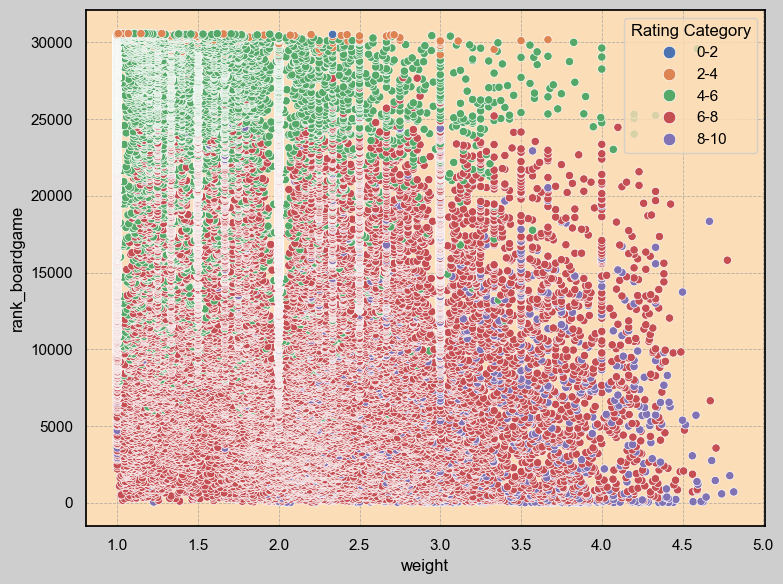

In [22]:
subplot_pairplot(df_plot, 4, 0,'weight',  'rank_boardgame', 'rating_cat',legend='brief')

<Axes: xlabel='release_year'>

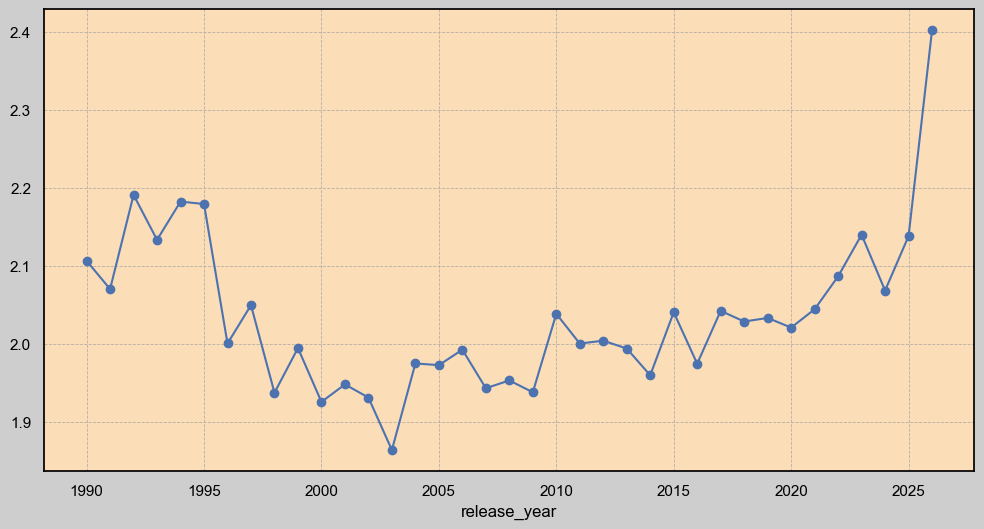

In [14]:
bgg_games_actual = bgg_games[bgg_games['release_year'] >= 1990]
# bgg_games_actual = bgg_games.copy()
bgg_games_actual.groupby('release_year')['weight'].mean().plot(kind='line', figsize=(12, 6), marker='o')


<Axes: xlabel='release_year'>

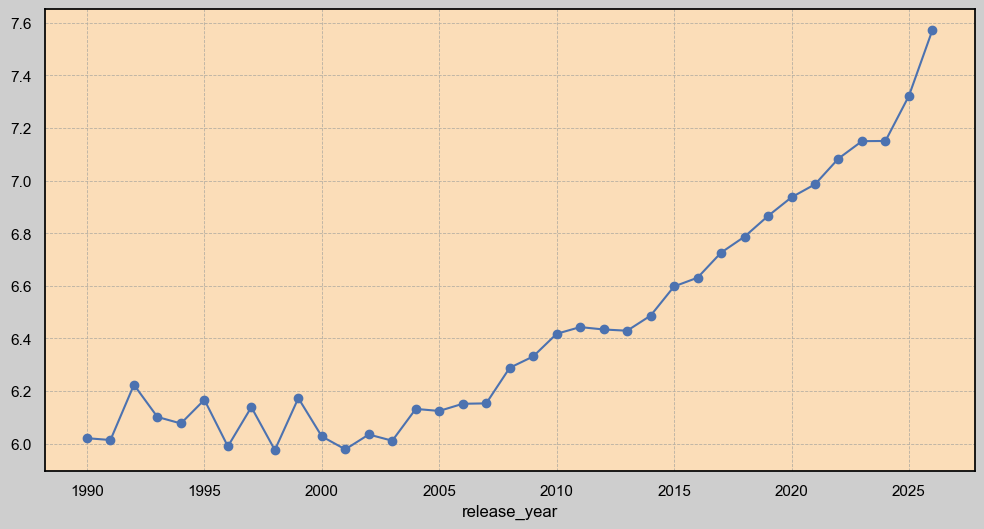

In [15]:
media_rating_por_anyo = bgg_games_actual.groupby('release_year')['average_rating'].mean()
media_rating_por_anyo.plot(kind='line', figsize=(12, 6), marker='o')

<BarContainer object of 37 artists>

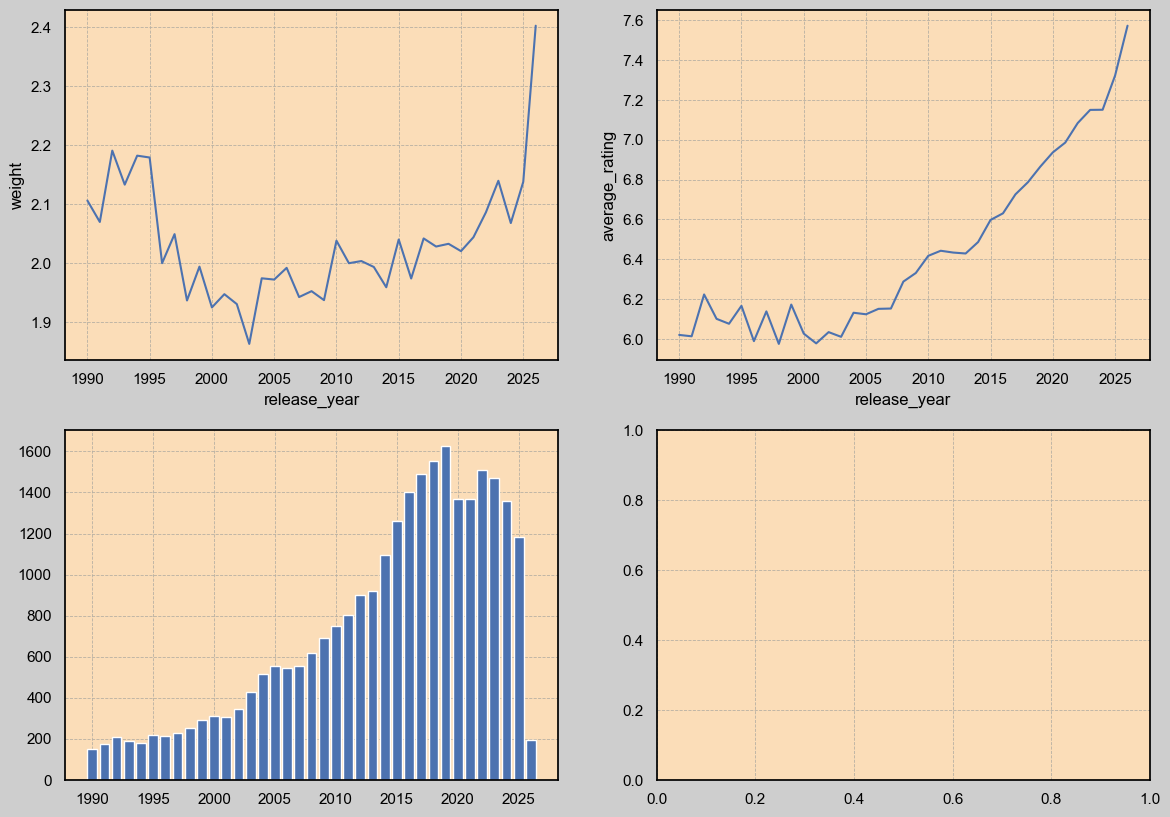

In [16]:
datos = bgg_games_actual.groupby('release_year').agg({
    'weight': 'mean',
    'average_rating': 'mean',
    'name': 'count'
    }).reset_index()
fig,ax = plt.subplots(2,2, figsize=(14, 10))
ax00 = ax[0,0]
sns.lineplot(data=datos, x='release_year', y='weight', ax=ax00)
ax01 = ax[0,1]
sns.lineplot(data=datos, x='release_year', y='average_rating', ax=ax01)
ax10 = ax[1,0]
ax10.bar(datos['release_year'], datos['name'])

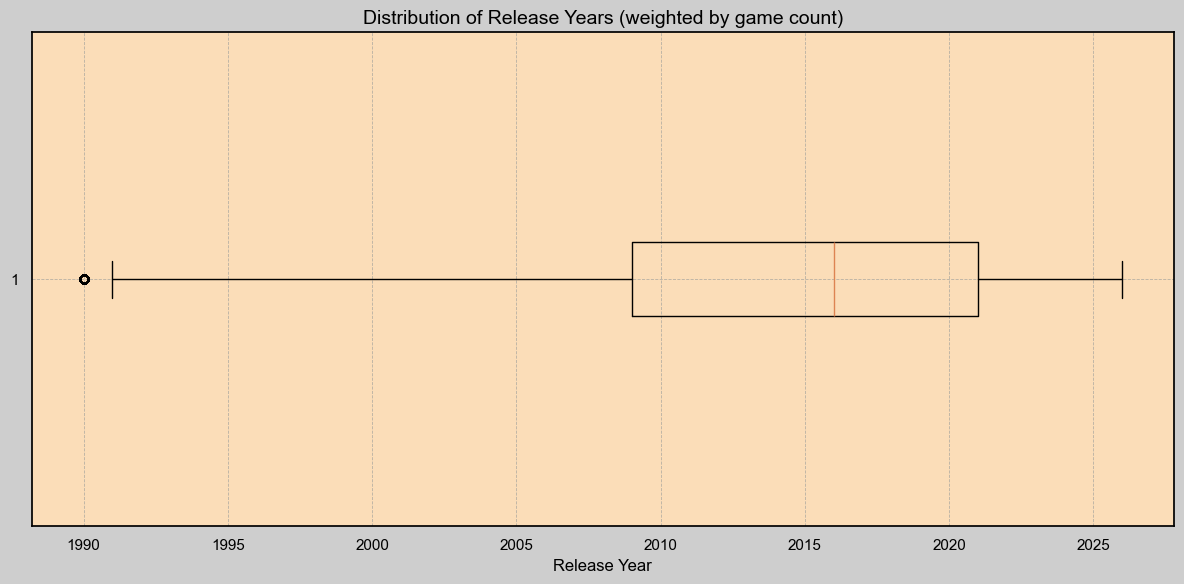

count    27234.000000
mean      2014.144158
std          8.443131
min       1990.000000
25%       2009.000000
50%       2016.000000
75%       2021.000000
max       2026.000000
dtype: float64

In [17]:
# Crear una lista con años repetidos según el conteo de juegos
years_expanded = []
for _, row in datos.iterrows():
    years_expanded.extend([row['release_year']] * int(row['name']))
years_expanded = pd.Series(years_expanded)
# Crear el boxplot
fig, ax_box = plt.subplots(figsize=(12, 6))
ax_box.boxplot(years_expanded, vert=False)
ax_box.set_xlabel('Release Year', fontsize=12)
ax_box.set_title('Distribution of Release Years (weighted by game count)', fontsize=14)
plt.tight_layout()
plt.show()

years_expanded.describe()

In [ ]:
sns.boxplot(data=bgg_games_actual, x='rating_cat', y='max_players', orient='h')
bgg_games_actual['max_players'].describe()

NameError: name 'sns' is not defined